<a href="https://colab.research.google.com/github/victoriousvictor42/FUTURE_DS_03/blob/main/College_Event_Feedback_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# College Event Feedback Analysis

---
## 1 Introduction

1.   List item
2.   List item





*   🔹 Task: Analyze student event
feedback to uncover satisfaction trends and
suggest improvements using survey data.
*   🔹 Skills Gained: Data cleaning, sentiment analysis, survey insights, charting, NLP.
* 🔹 Tools: Google Colab, pandas, TextBlob/VADER, seaborn, Google Forms (CSV).






## 2. Importing Libraries


In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Loading the datasets

In [2]:
# load the dataset
df = pd.read_csv("/content/Event_feedback.csv")

## 4. Performing Exploratory Data Analysis (EDA)

---



In [3]:
# we will start by seeing the first 5 rows
df.head()

,Student_ID,Event_Name,Organization_Rating,Content_Rating,Engagement_Level,Venue_Rating,Speaker_Performance,Event_Duration,Recommendation,Feedback
0,1,Tech Fest,5,4,High,5,5,3 hrs,Yes,Well organized and fun
1,2,Sports Meet,4,3,Medium,4,3,2 hrs,Yes,Enjoyed the matches
2,3,Cultural Night,3,5,Low,2,4,5 hrs,No,Too crowded
3,4,Workshop,5,4,High,4,5,4 hrs,Yes,Very informative
4,5,Guest Lecture,4,4,Medium,5,5,2 hrs,Yes,Inspirational talk


In [4]:
# then check out the last five rows
df.tail()

,Student_ID,Event_Name,Organization_Rating,Content_Rating,Engagement_Level,Venue_Rating,Speaker_Performance,Event_Duration,Recommendation,Feedback
15,16,Tech Fest,4,4,Medium,4,5,3 hrs,Yes,Good initiative
16,17,Sports Meet,5,5,High,5,5,2 hrs,Yes,Great participation
17,18,Cultural Night,3,3,Low,2,3,5 hrs,No,Boring at times
18,19,Workshop,5,5,High,5,5,4 hrs,Yes,Interesting workshop
19,20,Guest Lecture,4,4,Medium,4,4,2 hrs,Yes,Loved the session


In [5]:
df.columns

Index(['Student_ID', 'Event_Name', 'Organization_Rating', 'Content_Rating',
       'Engagement_Level', 'Venue_Rating', 'Speaker_Performance',
       'Event_Duration', 'Recommendation', 'Feedback'],
      dtype='object')

The columns names are good to go because they are uniform.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Student_ID           20 non-null     int64 
 1   Event_Name           20 non-null     object
 2   Organization_Rating  20 non-null     int64 
 3   Content_Rating       20 non-null     int64 
 4   Engagement_Level     20 non-null     object
 5   Venue_Rating         20 non-null     int64 
 6   Speaker_Performance  20 non-null     int64 
 7   Event_Duration       20 non-null     object
 8   Recommendation       20 non-null     object
 9   Feedback             20 non-null     object
dtypes: int64(5), object(5)
memory usage: 1.7+ KB


There are 5 integer columns and 5 character (object) columns.

In [7]:
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns")

There are 20 rows and 10 columns


In [8]:
df.describe()

,Student_ID,Organization_Rating,Content_Rating,Venue_Rating,Speaker_Performance
count,20.00000,20.000000,20.00000,20.000000,20.000000
mean,10.50000,4.200000,4.15000,4.100000,4.350000
std,5.91608,0.767772,0.74516,0.967906,0.812728
min,1.00000,3.000000,3.00000,2.000000,3.000000
25%,5.75000,4.000000,4.00000,4.000000,4.000000
50%,10.50000,4.000000,4.00000,4.000000,5.000000
75%,15.25000,5.000000,5.00000,5.000000,5.000000
max,20.00000,5.000000,5.00000,5.000000,5.000000


The mean of Organization_Rating, Content_Rating, Venue_Rating, and Speaker_Performance is 4.20, 4.15, 4.10, and 4.35 respectively.

## 5. Data Cleaning
---
### 5.1 Missing values



In [20]:
df.isnull().sum()

,0
Student_ID,0
Event_Name,0
Organization_Rating,0
Content_Rating,0
Engagement_Level,0
Venue_Rating,0
Speaker_Performance,0
Event_Duration,0
Recommendation,0
Feedback,0


There is not a single missing value

### 5.2 Duplicates

In [26]:
print(df.duplicated())

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
dtype: bool


Each row is unique.

---

We are now going to data visualization section for insights

## 6. Data Visualization
---
### 6.1 Recommendation distribution

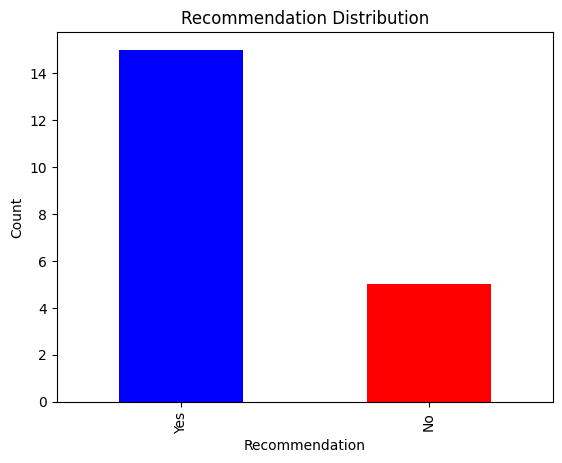

In [11]:
# Recommendation distribution (Yes vs No)
recommendation_counts = df['Recommendation'].value_counts()
recommendation_counts.plot(kind='bar', color=['blue', 'red'])
plt.title('Recommendation Distribution')
plt.xlabel('Recommendation')
plt.ylabel('Count')
plt.show()

### 6.2 Engagement distribution




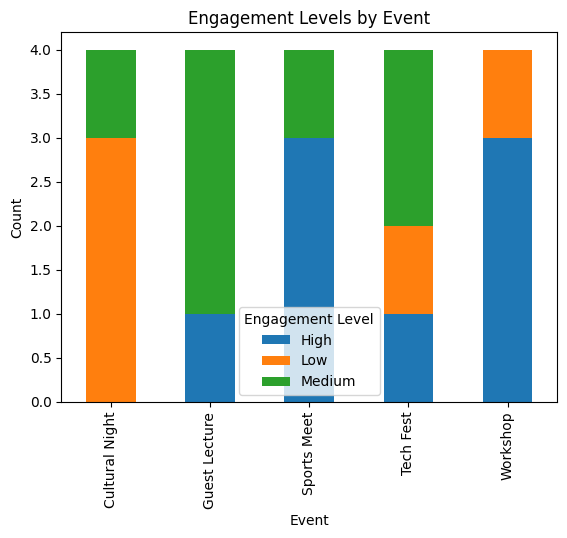

In [30]:
# We will have to count the engagement levels for each event
engagement_by_event = df.groupby('Event_Name')['Engagement_Level'].value_counts().unstack().fillna(0)
engagement_by_event.plot(kind='bar', stacked=True)
plt.title('Engagement Levels by Event')
plt.xlabel('Event')
plt.ylabel('Count')
plt.legend(title='Engagement Level')
plt.show()

### 6.3 Average ratings by Event

Average Ratings by Event:
                 Organization_Rating  Content_Rating  Venue_Rating  \
Event_Name                                                          
Cultural Night                 3.25            3.50           2.5   
Guest Lecture                  4.50            4.25           4.5   
Sports Meet                    4.50            4.25           4.5   
Tech Fest                      4.50            4.25           4.5   
Workshop                       4.25            4.50           4.5   

                Speaker_Performance  
Event_Name                           
Cultural Night                 3.25  
Guest Lecture                  4.75  
Sports Meet                    4.25  
Tech Fest                      4.75  
Workshop                       4.75  


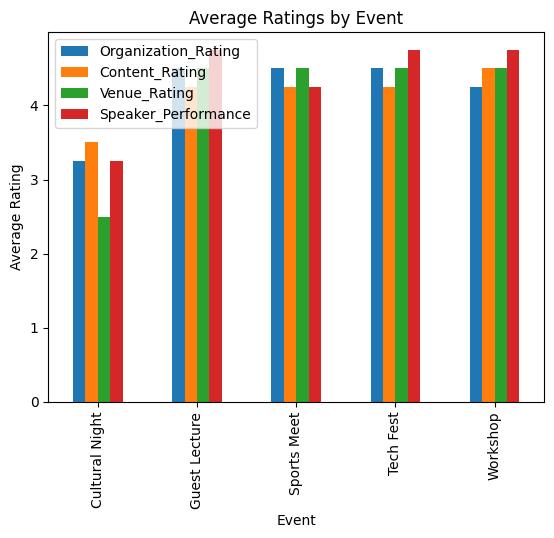

In [19]:
avg_ratings = df.groupby('Event_Name')[['Organization_Rating', 'Content_Rating', 'Venue_Rating', 'Speaker_Performance']].mean()
print('Average Ratings by Event:\n', avg_ratings)
avg_ratings.plot(kind='bar')
plt.title('Average Ratings by Event')
plt.xlabel('Event')
plt.ylabel('Average Rating')
plt.show()

### 6.4 Sentiment Distribution from feedback

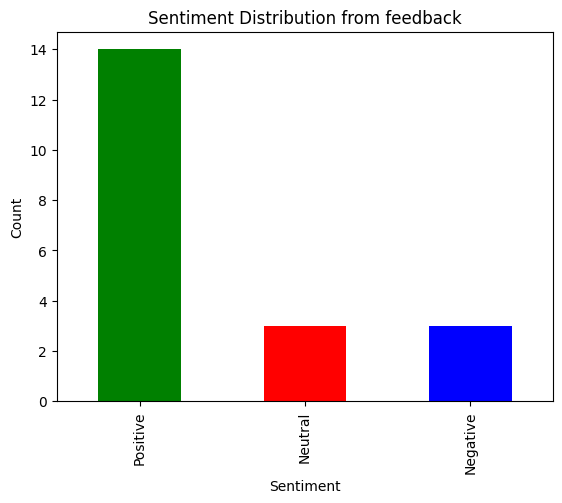

In [31]:
from textblob import TextBlob

# function to get sentiment polarity
def get_sentiment(text):
  polarity = TextBlob(text).sentiment.polarity
  if polarity > 0.1:
    return 'Positive'
  elif polarity < -0.1:
    return 'Negative'
  else:
    return 'Neutral'

# Apply function to Feedback column
df['Sentiment'] = df['Feedback'].apply(get_sentiment)

# Sentiment distribution
sentiment_counts = df['Sentiment'].value_counts()
sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Sentiment Distribution from feedback')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [33]:
print("There are:", sentiment_counts['Positive'], "positive feedback")
print("There are:", sentiment_counts['Negative'], "negative feedback")
print("There are:", sentiment_counts['Neutral'], "neutral feedback")

There are: 14 positive feedback
There are: 3 negative feedback
There are: 3 neutral feedback


### 6.5 Most common words in Student Feedback

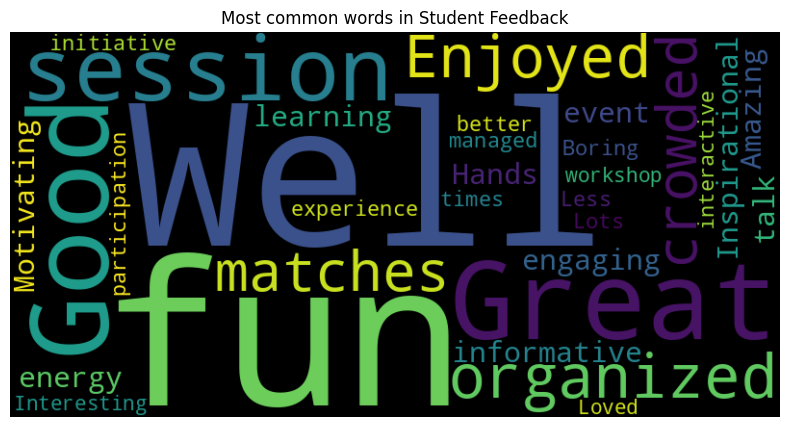

In [35]:
from wordcloud import WordCloud

# combine all feedback into one text
feedback_text = ' '.join(df['Feedback'].astype(str))

# create word cloud
wordcloud = WordCloud(width=800, height=400, background_color='Black').generate(feedback_text)

# show wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most common words in Student Feedback')
plt.show()

We can see that fun and well are the most common words.